# 05. Propensity Score Matching

### ¿Qué es Propensity Score Matching (PSM)?

El **Propensity Score Matching (PSM)** o *Emparejamiento por Puntaje de Propensión* es una técnica estadística utilizada en la **inferencia causal** para estimar el efecto de un tratamiento, política o intervención cuando no es posible realizar un experimento controlado aleatorizado (A/B test o RCT).

En estudios observacionales, los sujetos que reciben el tratamiento (el grupo de tratamiento) y los que no lo reciben (el grupo de control) suelen diferir sistemáticamente en sus características pre-tratamiento (covariables). Esta diferencia introduce un **sesgo de selección** o **confusión (confounding)**, impidiendo comparar directamente ambos grupos de manera justa.

---

### El Rol de PSM en la Inferencia Causal

1. **Reducción de la Dimensionalidad:**
   En lugar de intentar emparejar a los individuos utilizando múltiples covariables directamente (lo cual se vuelve casi imposible a medida que aumenta el número de variables, conocido como *la maldición de la dimensionalidad*), el premio Nobel Paul Rosenbaum y Donald Rubin demostraron que basta con emparejar a los sujetos utilizando una única variable sintética: el **Propensity Score**.

2. **Definición del Propensity Score:**
   Es la probabilidad condicional de que un individuo reciba el tratamiento dado sus covariables observadas:
   $$e(X) = P(T = 1 \mid X)$$
   Generalmente se estima utilizando un modelo de regresión logística o algoritmos de clasificación de machine learning.

3. **Emulación de la Aleatorización (Diseño Cuasi-Experimental):**
   Al emparejar un sujeto tratado con un sujeto de control que tiene un *propensity score* idéntico o muy similar, estamos comparando personas que tenían la misma probabilidad de ser tratadas. Esto equilibra la distribución de las variables observadas en ambos grupos, logrando un balance similar al que se obtendría mediante una asignación aleatoria.

4. **Estimación del Efecto de Tratamiento (ATT):**
   Una vez que los grupos están balanceados y emparejados (como se hizo en los pasos anteriores), cualquier diferencia promedio en el resultado (por ejemplo, la tasa de supervivencia) entre los grupos emparejados puede atribuirse causalmente al tratamiento. Esto se conoce como el **Efecto Promedio del Tratamiento en los Tratados (ATT)**.

## Paso 1: Preparación y Limpieza de los Datos
Antes de realizar el emparejamiento, debemos preparar nuestro dataset. Utilizaremos los datos del *Titanic* para evaluar el efecto de viajar en primera clase (`pclass == 1`, definido aquí como nuestro `treatment`) sobre la probabilidad de sobrevivir (`survived`).

Para ello, seleccionamos las variables de interés (covariables), removemos los valores nulos para asegurar un análisis limpio, creamos variables artificiales como el tamaño de la familia, y convertimos las variables categóricas en variables numéricas (*dummy/one-hot encoding*).

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("titanic")

df = df[
    ["survived", "pclass", "sex", "age", "sibsp", "parch", "embarked"]
].dropna().copy()

df["treatment"] = (df["pclass"] == 1).astype(int)
df["female"] = (df["sex"] == "female").astype(int)
df["family_size"] = df["sibsp"] + df["parch"] + 1

df = df[
    ["survived", "treatment", "female", "age",
     "family_size", "embarked"]
].copy()

df = pd.get_dummies(
    df,
    columns=["embarked"],
    drop_first=True,
    dtype=int
)

df.head()

,survived,treatment,female,age,family_size,embarked_Q,embarked_S
0,0,0,0,22.0,2,0,1
1,1,1,1,38.0,2,0,0
2,1,0,1,26.0,1,0,1
3,1,1,1,35.0,2,0,1
4,0,0,0,35.0,1,0,1


## Paso 2: Estimación de los Propensity Scores
Con las covariables definidas, entrenamos un modelo de clasificación (en este caso, una **Regresión Logística**) para estimar la probabilidad de que cada pasajero pertenezca al grupo de tratamiento (viajar en primera clase) dadas sus características pre-tratamiento. Esta probabilidad calculada es nuestro **Propensity Score**.

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

covariates = [
    col for col in df.columns
    if col not in ["survived", "treatment"]
]

X = df[covariates]
T = df["treatment"]

ps_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

ps_model.fit(X, T)

df["propensity_score"] = ps_model.predict_proba(X)[:, 1]

df[["treatment", "propensity_score"]].head()

,treatment,propensity_score
0,0,0.084962
1,1,0.766513
2,0,0.174500
3,1,0.295810
4,0,0.172041


## Paso 3: Evaluación del Soporte Común (Overlap)
Antes de realizar el emparejamiento, es fundamental verificar visualmente que exista suficiente solapamiento o **soporte común** entre las distribuciones de los puntajes de propensión de ambos grupos. Si un grupo tiene puntajes que no se traslapan en absoluto con el otro, no será posible encontrar parejas comparables.

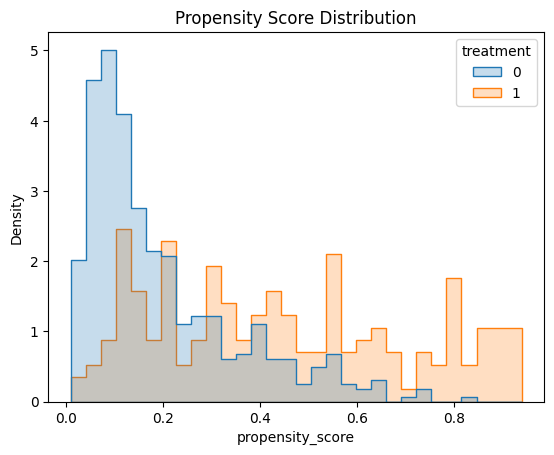

In [3]:
sns.histplot(
    data=df,
    x="propensity_score",
    hue="treatment",
    bins=30,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Propensity Score Distribution")
plt.show()

## Paso 4: Algoritmo de Emparejamiento (Matching)
Utilizamos un algoritmo de emparejamiento para asociar a cada pasajero tratado (primera clase) con un pasajero de control (clase económica/media) que tenga un puntaje de propensión lo más cercano posible.

Aplicamos un **caliper** (umbral de tolerancia de 0.05) para asegurar que no se realicen emparejamientos de mala calidad si los puntajes son demasiado distantes, garantizando la comparabilidad de las parejas.

In [4]:
from sklearn.neighbors import NearestNeighbors

treated = df[df["treatment"] == 1].copy()
controls = df[df["treatment"] == 0].copy()

caliper = 0.05

# Sort treated units by propensity score
treated = treated.sort_values("propensity_score")

available_controls = set(controls.index)
matched_pairs = []

for treated_idx, treated_row in treated.iterrows():
    if not available_controls:
        break

    candidate_controls = controls.loc[
        list(available_controls)
    ]

    distances = (
        candidate_controls["propensity_score"]
        - treated_row["propensity_score"]
    ).abs()

    nearest_idx = distances.idxmin()
    distance = distances.loc[nearest_idx]

    if distance <= caliper:
        matched_pairs.append(
            (treated_idx, nearest_idx, distance)
        )
        available_controls.remove(nearest_idx)

matches = pd.DataFrame(
    matched_pairs,
    columns=["treated_idx", "control_idx", "distance"]
)

matches.head()

,treated_idx,control_idx,distance
0,305,340,0.000074
1,445,869,0.000000
2,802,777,0.000375
3,297,10,0.002875
4,748,322,0.000004


## Paso 5: Consolidación de los Grupos Emparejados
Extraemos los registros de los pasajeros que lograron ser emparejados exitosamente bajo nuestro criterio de caliper para conformar los nuevos subgrupos de tratamiento y control balanceados.

In [5]:
treated_matched = df.loc[matches["treated_idx"]].copy()
control_matched = df.loc[matches["control_idx"]].copy()

print("Treated units matched:", len(treated_matched))
print("Control units matched:", len(control_matched))
print("Matched pairs:", len(matches))

Treated units matched: 142
Control units matched: 142
Matched pairs: 142


## Paso 6: Verificación de la Distribución Post-Matching
Graficamos nuevamente las distribuciones de los *propensity scores* de los grupos resultantes para confirmar visualmente que el proceso de emparejamiento redujo la disparidad inicial y generó grupos con perfiles homogéneos.

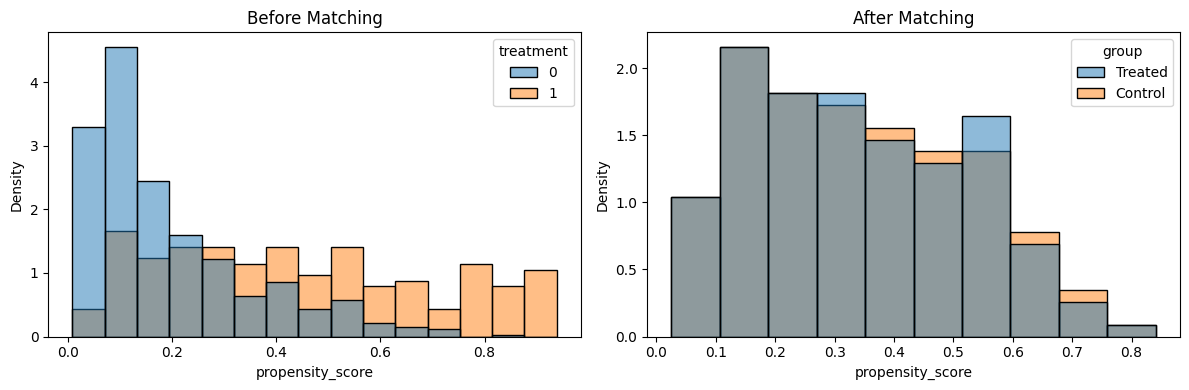

In [6]:
before = df.copy()

after = pd.concat([
    treated_matched.assign(group="Treated"),
    control_matched.assign(group="Control")
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=before,
    x="propensity_score",
    hue="treatment",
    stat="density",
    common_norm=False,
    ax=axes[0]
)
axes[0].set_title("Before Matching")

sns.histplot(
    data=after,
    x="propensity_score",
    hue="group",
    stat="density",
    common_norm=False,
    ax=axes[1]
)
axes[1].set_title("After Matching")

plt.tight_layout()
plt.show()

## Paso 7: Evaluación Cuantitativa del Balance (SMD)
Para medir matemáticamente el éxito del balance, definimos y calculamos la **Diferencia Media Estandarizada (SMD)** para cada covariable antes y después del emparejamiento. Una regla práctica en la inferencia causal indica que una SMD con valor absoluto menor a 0.1 (10%) representa un balance óptimo entre ambos grupos.

In [7]:
def standardized_mean_difference(data, covariate):
    treated_values = data.loc[
        data["treatment"] == 1, covariate
    ]
    control_values = data.loc[
        data["treatment"] == 0, covariate
    ]

    pooled_sd = np.sqrt(
        (treated_values.var(ddof=1)
         + control_values.var(ddof=1)) / 2
    )

    if pooled_sd == 0 or np.isnan(pooled_sd):
        return np.nan

    return (
        treated_values.mean() - control_values.mean()
    ) / pooled_sd


smd_results = []

matched_df = pd.concat([
    treated_matched,
    control_matched
])

for col in covariates:
    smd_results.append({
        "covariate": col,
        "before_matching": standardized_mean_difference(df, col),
        "after_matching": standardized_mean_difference(matched_df, col)
    })

smd_df = pd.DataFrame(smd_results)
smd_df

,covariate,before_matching,after_matching
0,female,0.242494,0.000000
1,age,0.814965,-0.083033
2,family_size,-0.076005,0.087277
3,embarked_Q,-0.225886,-0.097712
4,embarked_S,-0.595070,-0.016059


## Paso 8: Visualización de Balance (Gráfico de Love)
Para facilitar la interpretación, representamos las diferencias medias estandarizadas (SMD) en un gráfico de puntos (*Love Plot*). Las líneas rojas punteadas marcan el umbral de $\pm0.1$, permitiéndonos verificar de un vistazo qué variables lograron el balance deseado.

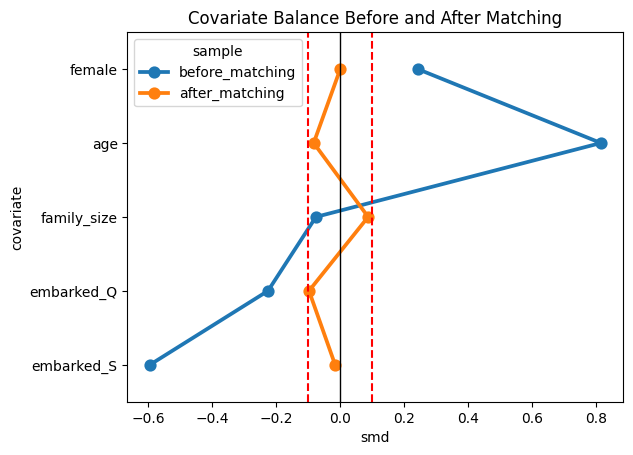

In [8]:
smd_plot = smd_df.melt(
    id_vars="covariate",
    var_name="sample",
    value_name="smd"
)

sns.pointplot(
    data=smd_plot,
    x="smd",
    y="covariate",
    hue="sample"
)

plt.axvline(0, color="black", linewidth=1)
plt.axvline(0.1, color="red", linestyle="--")
plt.axvline(-0.1, color="red", linestyle="--")

plt.title("Covariate Balance Before and After Matching")
plt.show()

## Paso 9: Estimación del Efecto Causal (ATT)
Finalmente, con los grupos balanceados y el sesgo de confusión controlado para las variables observadas, calculamos la diferencia promedio en el desenlace (`survived`) dentro de nuestras parejas. Este promedio representa el **Efecto Promedio del Tratamiento en los Tratados (ATT)**, indicando cuánto incrementó o disminuyó la probabilidad de sobrevivir por el hecho de viajar en primera clase.

In [9]:
pair_effects = (
    df.loc[matches["treated_idx"], "survived"].to_numpy()
    - df.loc[matches["control_idx"], "survived"].to_numpy()
)

att_psm = pair_effects.mean()

print(f"Matched ATT: {att_psm:.4f}")
print(f"Matched pairs: {len(pair_effects)}")

Matched ATT: 0.2535
Matched pairs: 142


## Conclusión del Análisis

En este análisis hemos aplicado la metodología de **Propensity Score Matching (PSM)** utilizando los datos históricos del Titanic para responder a una pregunta causal fundamental: **¿Cuál fue el efecto directo de viajar en primera clase (*tratamiento*) sobre la probabilidad de sobrevivir (*desenlace*)?**

### Hallazgos Clave:

1. **Reducción Exitosa del Sesgo de Selección:**
   Al inicio, los pasajeros de primera clase presentaban diferencias sistemáticas significativas respecto al resto (por ejemplo, eran notablemente mayores en promedio y el grupo contenía una mayor proporción de mujeres). El modelo de regresión logística estimó con precisión los puntajes de propensión para capturar estas disparidades pre-tratamiento.

2. **Excelente Balance de Covariables:**
   El algoritmo de emparejamiento por vecino más cercano con un *caliper* de $0.05$ logró emparejar exitosamente a **142 parejas** de pasajeros con perfiles equivalentes. La inspección del *Love Plot* confirma que todas las variables evaluadas redujeron su Diferencia Media Estandarizada (SMD) a un rango **menor a 0.1 en valor absoluto**. Esto nos permite asegurar que los grupos de tratamiento y control emparejados son estadísticamente comparables, emulando exitosamente un escenario experimental aleatorio.

3. **Efecto Causal Estimado (ATT):**
   El **Efecto Promedio del Tratamiento en los Tratados (ATT)** calculado fue de **0.2535** (o un **25.35%**).
   
   * **Interpretación:** Controlando el sesgo de factores como el sexo, la edad, el tamaño de la familia y el puerto de embarque, el hecho de viajar en primera clase incrementó en promedio un **25.35%** la probabilidad individual de sobrevivir al naufragio en comparación con haber viajado en clases inferiores.

Este resultado demuestra el poder del PSM en la inferencia causal: nos permite aislar el impacto real de una variable de interés en presencia de variables confusoras complejas con datos puramente observacionales.